In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Nie udało się znaleźć katalogu projektu z plikiem pyproject.toml.")

# Termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

# Inner size of chessboard (liczba wewnętrznych narożników)
width = 8
height = 5
square_size = 0.029  # 0.025 meters

# Prepare object points
objp = np.zeros((height * width, 1, 3), np.float64)
objp[:, 0, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)
objp = objp * square_size  # Create real-world coordinates

# Arrays to store object points and image points
objpoints = []  # 3D points in real-world space
imgpoints = []  # 2D points in image plane
used_image_paths = []

base_dir = find_project_root(Path.cwd())
image_dir = base_dir / "data" / "photos"
image_paths = sorted(
    path for path in image_dir.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
 )

if not image_paths:
    raise FileNotFoundError(f"Nie znaleziono obrazów w katalogu: {image_dir}")

image_size = None

for image_path in image_paths:
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"Nie udało się wczytać obrazu: {image_path.name}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    current_image_size = (img.shape[1], img.shape[0])

    if image_size is None:
        image_size = current_image_size
    elif current_image_size != image_size:
        print(f"Pomijam {image_path.name} z powodu innego rozmiaru: {current_image_size}")
        continue

    ret, corners = cv2.findChessboardCorners(
        gray,
        (width, height),
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE,
    )

    if not ret:
        ret, corners = cv2.findChessboardCornersSB(gray, (width, height))

    if not ret:
        print(f"Nie wykryto szachownicy {width}x{height} na obrazie: {image_path.name}")
        continue

    Y, X = gray.shape
    minRx = corners[:, :, 0].min()
    maxRx = corners[:, :, 0].max()
    minRy = corners[:, :, 1].min()
    maxRy = corners[:, :, 1].max()
    border_threshold_x = X / 12
    border_threshold_y = Y / 12
    too_close_to_border = (
        minRx < border_threshold_x
        or minRy < border_threshold_y
        or maxRx > X - border_threshold_x
        or maxRy > Y - border_threshold_y
    )

    if too_close_to_border:
        print(f"Pomijam {image_path.name} - narożniki są zbyt blisko krawędzi.")
        continue

    objpoints.append(objp.copy())
    corners2 = cv2.cornerSubPix(gray, corners, (3, 3), (-1, -1), criteria)
    imgpoints.append(corners2)
    used_image_paths.append(image_path)

print(f"Znaleziono {len(image_paths)} obrazów w {image_dir}")
print(f"Do kalibracji użyto {len(used_image_paths)} obrazów")
print(f"Rozmiar obrazu: {image_size}")

Pomijam DSC00816.JPG - narożniki są zbyt blisko krawędzi.
Pomijam DSC00829.JPG - narożniki są zbyt blisko krawędzi.
Znaleziono 39 obrazów w /home/dbabiarczyk/studia/semestr10/camera_calibration/data/photos
Do kalibracji użyto 37 obrazów
Rozmiar obrazu: (3072, 1728)


In [2]:
# Calibration
N_OK = len(objpoints)

if N_OK == 0:
    raise RuntimeError("Brak poprawnie wykrytych wzorców szachownicy do kalibracji.")

K = np.zeros((3, 3))
D = np.zeros((4, 1))
rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]
tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]

ret, K, D, _, _ = cv2.fisheye.calibrate(
    objpoints,
    imgpoints,
    image_size,
    K,
    D,
    rvecs,
    tvecs,
    calibration_flags,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6),
)

# Rectify results
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), K, image_size, cv2.CV_16SC2
)

In [3]:
print("błąd średniokwadratowej projekcji wstecznej: ", ret)
print("K macierz wewnętrzna kamery: \n", K)
print("D współczynniki dystorsji: \n", D)
print("rvecs wektory rotacji: \n", rvecs)
print("tvecs wektory translacji: \n", tvecs)

błąd średniokwadratowej projekcji wstecznej:  2.1555804863803507
K macierz wewnętrzna kamery: 
 [[3.71832747e+03 0.00000000e+00 1.53849605e+03]
 [0.00000000e+00 3.72481824e+03 8.87360264e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
D współczynniki dystorsji: 
 [[  0.16185236]
 [ -1.38142665]
 [ 20.56438954]
 [-96.53185367]]
rvecs wektory rotacji: 
 [array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0

In [4]:
test_image_path = used_image_paths[0]
test_img = cv2.imread(str(test_image_path))

undistorted_image = cv2.remap(
    test_img,
    map1,
    map2,
    interpolation=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
 )

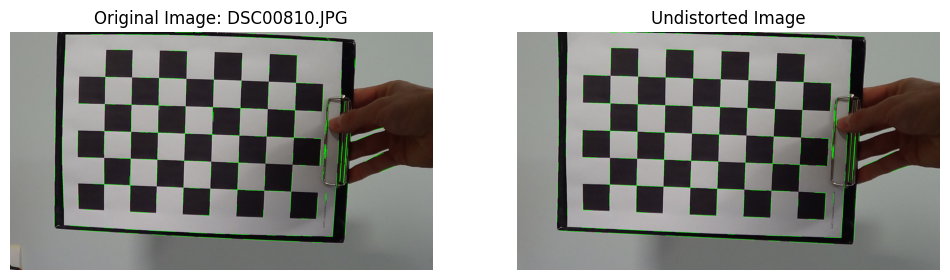

In [5]:
def detect_lines(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=50, maxLineGap=10)
    return lines

def draw_lines(image, lines):
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

lines_before = detect_lines(test_img)
lines_after = detect_lines(undistorted_image)

before_with_lines = test_img.copy()
after_with_lines = undistorted_image.copy()

draw_lines(before_with_lines, lines_before)
draw_lines(after_with_lines, lines_after)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(before_with_lines, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Original Image: {test_image_path.name}")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(after_with_lines, cv2.COLOR_BGR2RGB))
ax[1].set_title("Undistorted Image")
ax[1].axis("off")
plt.show()

Kalibracja dla wszystkich obrazów z katalogu `data/photos`:

In [6]:
corrected_images = []

for image_path in used_image_paths:
    original_image = cv2.imread(str(image_path))
    undistorted_image = cv2.remap(
        original_image,
        map1,
        map2,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
    )
    corrected_images.append((image_path, original_image, undistorted_image))

print(f"Przygotowano {len(corrected_images)} obrazów do porównania.")

Przygotowano 37 obrazów do porównania.


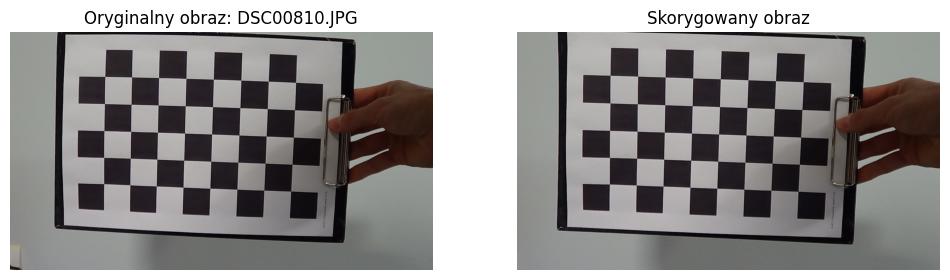

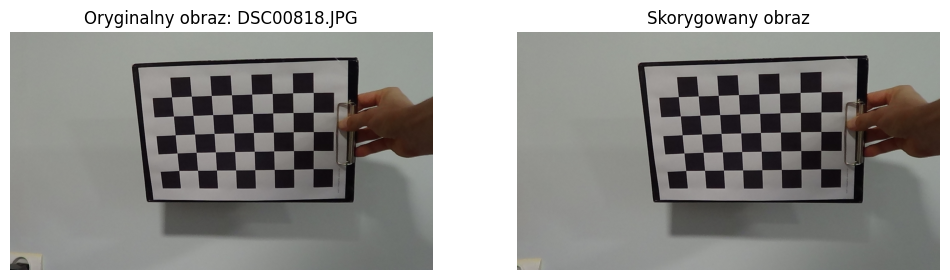

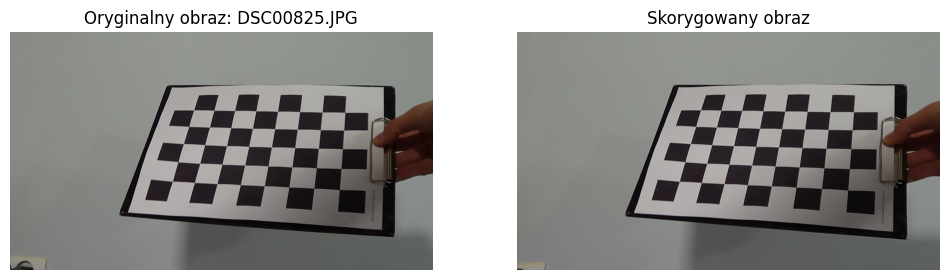

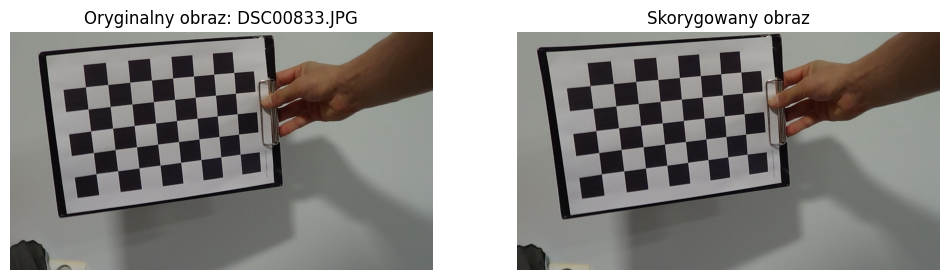

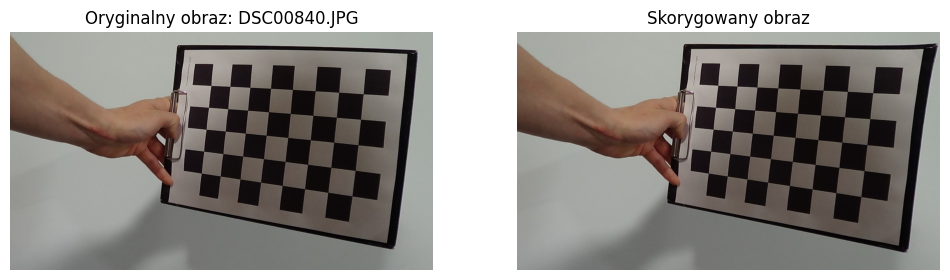

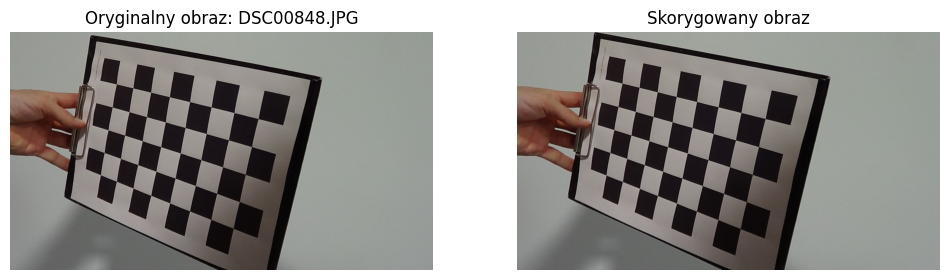

In [7]:
sample_indices = np.linspace(
    0,
    len(corrected_images) - 1,
    num=min(6, len(corrected_images)),
    dtype=int,
 )

for idx in sample_indices:
    image_path, original_image, corrected_image = corrected_images[idx]
    fig, ax = plt.subplots(1, 2, figsize=(12, 7))
    ax[0].set_title(f"Oryginalny obraz: {image_path.name}")
    ax[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(corrected_image, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Skorygowany obraz")
    ax[1].axis("off")
    plt.show()

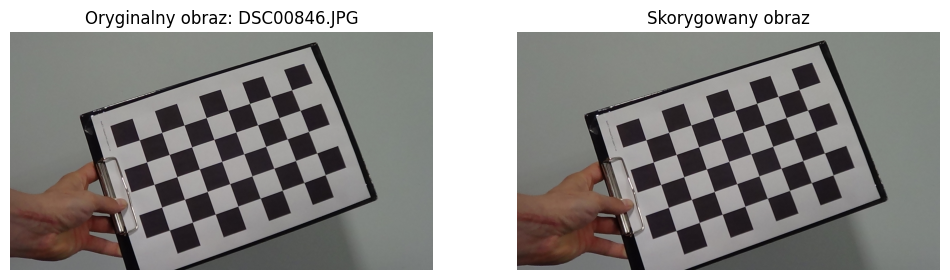

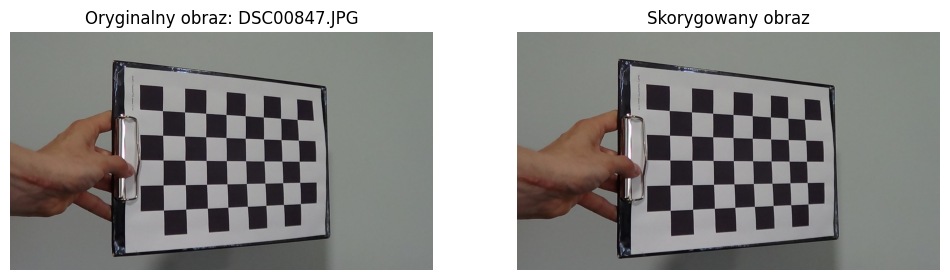

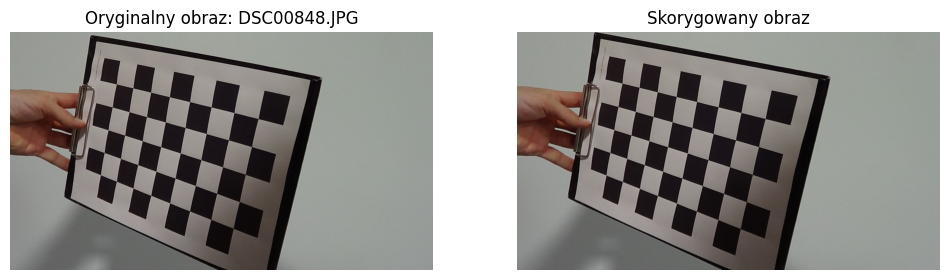

In [8]:
tail_images = corrected_images[-min(3, len(corrected_images)):]

for image_path, original_image, corrected_image in tail_images:
    fig, ax = plt.subplots(1, 2, figsize=(12, 7))
    ax[0].set_title(f"Oryginalny obraz: {image_path.name}")
    ax[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(corrected_image, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Skorygowany obraz")
    ax[1].axis("off")
    plt.show()